Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [2]:
df = pd.read_csv('/content/drive/MyDrive/PROYECT_6/train.csv')

Basic Exploration, Missing values and Data Types

In [3]:
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [4]:
df.shape

(10886, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [6]:
df.isnull().sum()

,0
datetime,0
season,0
holiday,0
workingday,0
weather,0
temp,0
atemp,0
humidity,0
windspeed,0
casual,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


In [9]:
categorical = df.select_dtypes(include='object').columns
categorical

Index(['datetime'], dtype='object')

In [10]:
numerical = df.select_dtypes(exclude='object').columns
numerical

Index(['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp',
       'humidity', 'windspeed', 'casual', 'registered', 'count'],
      dtype='object')

In [11]:
print(df['datetime'].value_counts())

datetime
2012-12-19 23:00:00    1
2011-01-01 00:00:00    1
2011-01-01 01:00:00    1
2011-01-01 02:00:00    1
2011-01-01 03:00:00    1
                      ..
2011-01-01 10:00:00    1
2011-01-01 09:00:00    1
2011-01-01 08:00:00    1
2011-01-01 07:00:00    1
2011-01-01 06:00:00    1
Name: count, Length: 10886, dtype: int64


In [12]:
for col in numerical:
  print('\n')
  print(df[col].value_counts())



season
4    2734
2    2733
3    2733
1    2686
Name: count, dtype: int64


holiday
0    10575
1      311
Name: count, dtype: int64


workingday
1    7412
0    3474
Name: count, dtype: int64


weather
1    7192
2    2834
3     859
4       1
Name: count, dtype: int64


temp
14.76    467
26.24    453
28.70    427
13.94    413
18.86    406
22.14    403
25.42    403
16.40    400
22.96    395
27.06    394
24.60    390
12.30    385
21.32    362
17.22    356
13.12    356
29.52    353
10.66    332
18.04    328
20.50    327
30.34    299
9.84     294
15.58    255
9.02     248
31.16    242
8.20     229
27.88    224
23.78    203
32.80    202
11.48    181
19.68    170
6.56     146
33.62    130
5.74     107
7.38     106
31.98     98
34.44     80
35.26     76
4.92      60
36.90     46
4.10      44
37.72     34
36.08     23
3.28      11
0.82       7
38.54      7
39.36      6
2.46       5
1.64       2
41.00      1
Name: count, dtype: int64


atemp
31.060    671
25.760    423
22.725    406
20.455    40

Target Variable

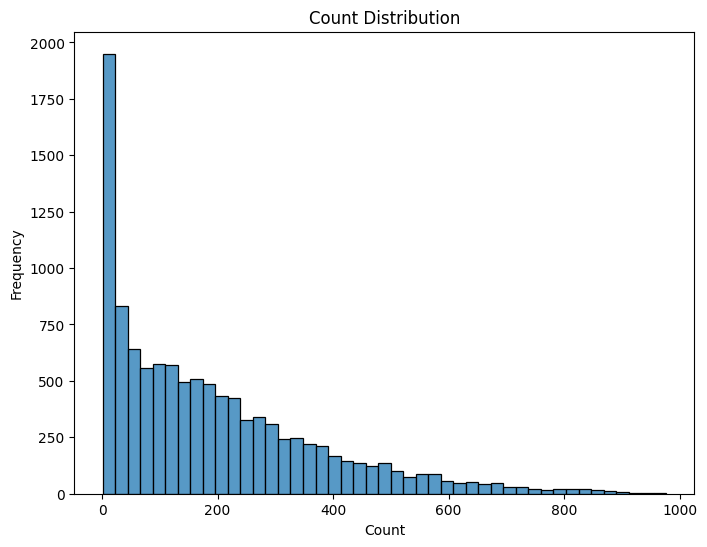

In [13]:
plt.figure(figsize=(8,6))
sns.histplot(df['count'])
plt.title('Count Distribution')
plt.xlabel('Count')
plt.ylabel('Frequency')
plt.show()

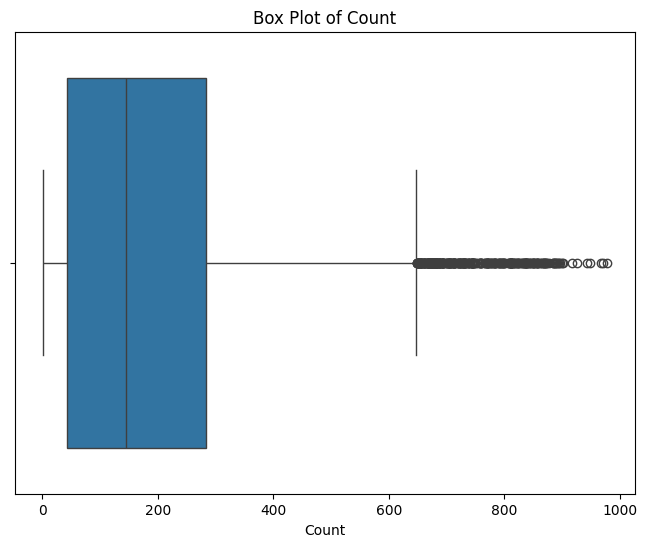

In [15]:
plt.figure(figsize=(8,6))
sns.boxplot(x='count', data=df)
plt.title('Box Plot of Count')
plt.xlabel('Count')
plt.show()

The target variable is positively skewed, with most observations concentrated at lower demand levels. Some high-demand outliers are present, but they likely represent real-world scenarios rather than data errors. Therefore, no transformation or outlier removal will be applied.

Feature Distributions

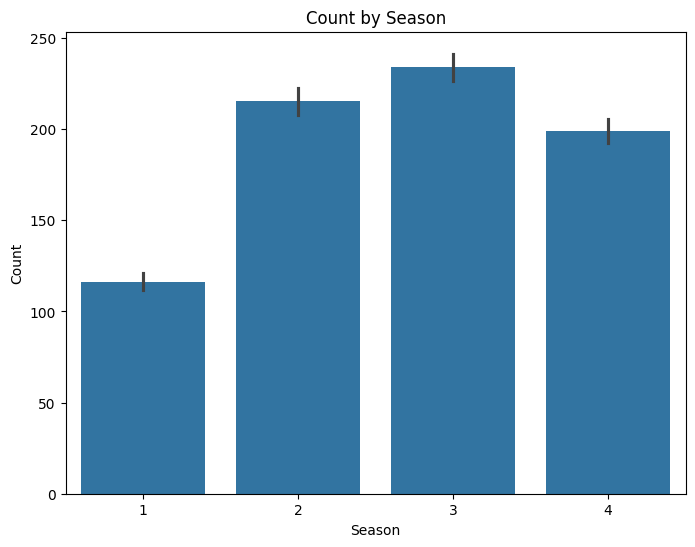

In [16]:
plt.figure(figsize=(8,6))
sns.barplot(x='season', y='count', data=df)
plt.title('Count by Season')
plt.xlabel('Season')
plt.ylabel('Count')
plt.show()

Bike demand varies across seasons. Season 3 shows the highest number of rentals, while season 1 has the lowest. The differences between season 2, 3 and 4 are relatively moderate, whereas season 1 exhibits substantially lower demand.

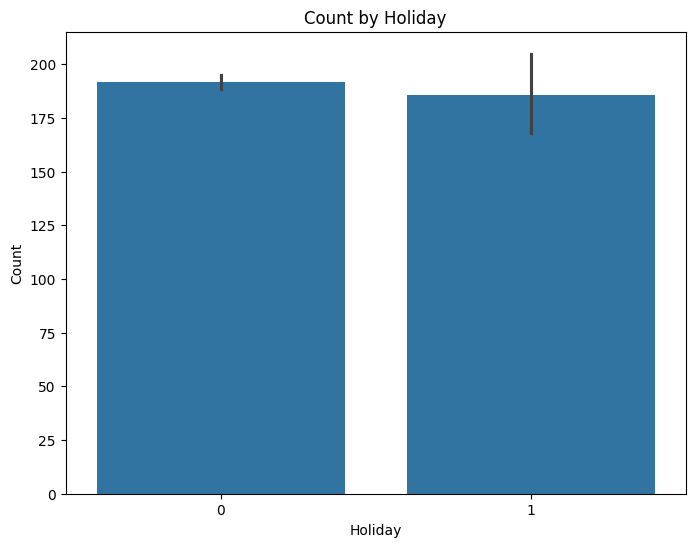

In [17]:
plt.figure(figsize=(8,6))
sns.barplot(x='holiday', y='count', data=df)
plt.title('Count by Holiday')
plt.xlabel('Holiday')
plt.ylabel('Count')
plt.show()

The average bike demand is very similar between holidays and non-holidays, suggesting that holidays alone may have a limited influence on rental demand. However, the variable will be retained for model training, allowing the algorithm to determine whether it provides useful predictive information when combined with other features.

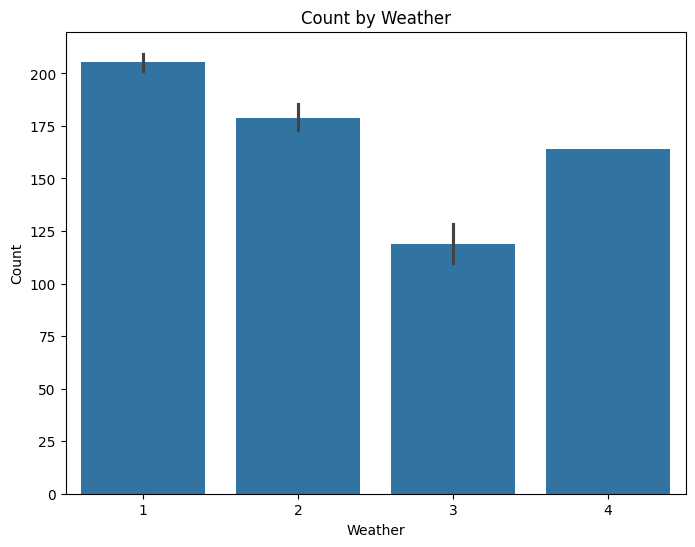

In [18]:
plt.figure(figsize=(8,6))
sns.barplot(x='weather', y='count', data=df)
plt.title('Count by Weather')
plt.xlabel('Weather')
plt.ylabel('Count')
plt.show()

Bike demand varies noticeably across different weather conditions. Better weather is associated with higher rental demand, while poorer weather results in substantially fewer rentals. This suggests that weather is likely to be an important predictive feature and should be retained for model training.

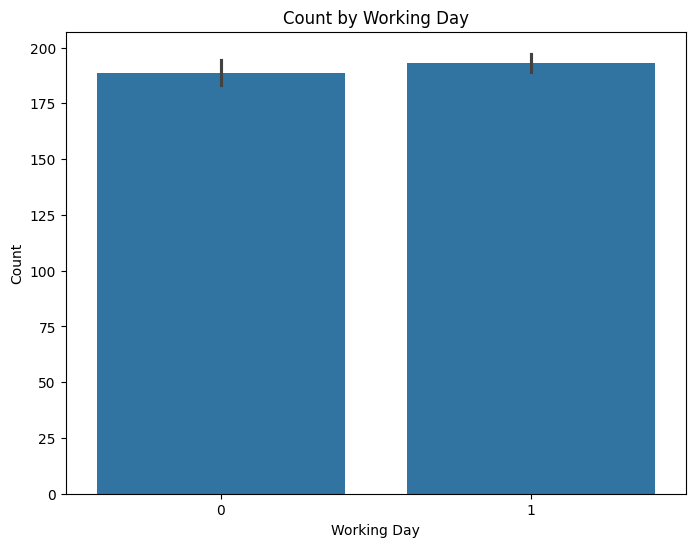

In [19]:
plt.figure(figsize=(8,6))
sns.barplot(x='workingday', y='count', data=df)
plt.title('Count by Working Day')
plt.xlabel('Working Day')
plt.ylabel('Count')
plt.show()

The bar plot shows only a small difference in average bike demand between working days and non-working days. This suggests that whether a day is a working day does not have a strong individual influence on rental demand. However, the variable will be retained for model training, as it may provide useful predictive information when combined with other features.

In [24]:
numerical = df[['temp', 'atemp', 'humidity', 'windspeed']].columns
numerical

Index(['temp', 'atemp', 'humidity', 'windspeed'], dtype='object')

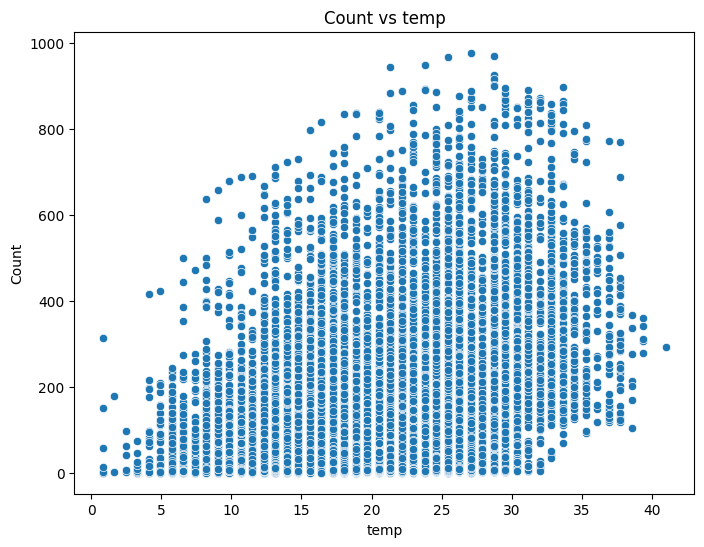

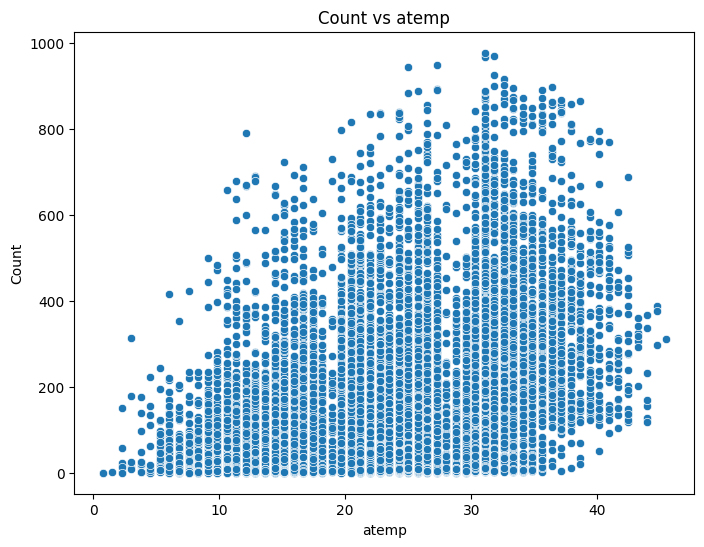

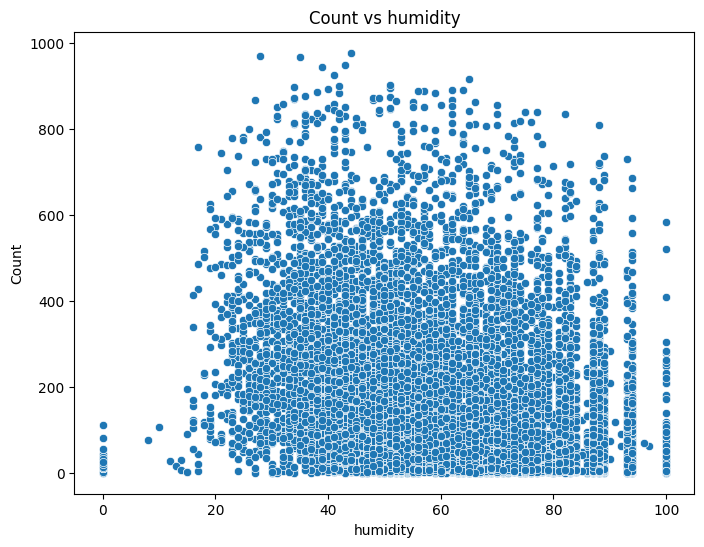

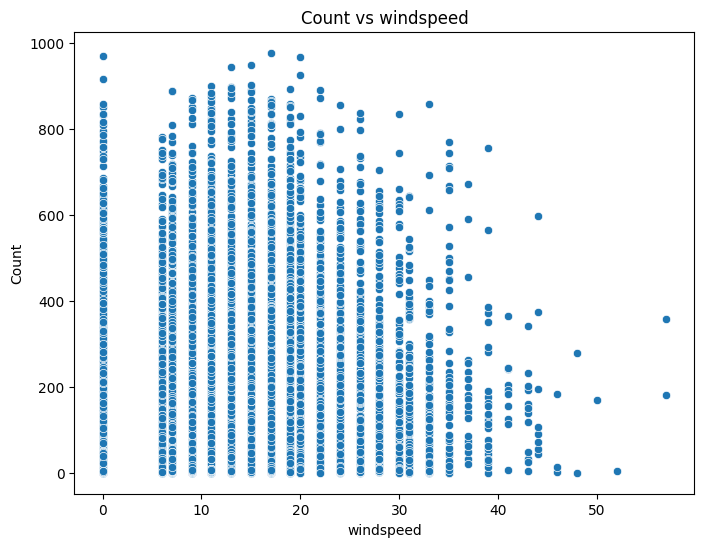

In [25]:
for col in numerical:
  plt.figure(figsize=(8,6))
  sns.scatterplot(x=col, y='count', data=df)
  plt.title(f'Count vs {col}')
  plt.xlabel(col)
  plt.ylabel('Count')
  plt.show()

Apparent temperature displays a similar positive relationship with bike demand. As perceived temperature increases, rental demand generally increases as well, suggesting that this feature may also contribute to model performance.

Wind speed shows a moderate negative relationship with bike demand. Higher wind speeds are generally associated with lower rental activity, suggesting that wind may negatively influence bicycle usage.

In [28]:
numerical = df[[
    'temp',
    'atemp',
    'humidity',
    'windspeed',
    'casual',
    'registered',
    'count'
]].columns
numerical

Index(['temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered',
       'count'],
      dtype='object')

Correlation Analysis

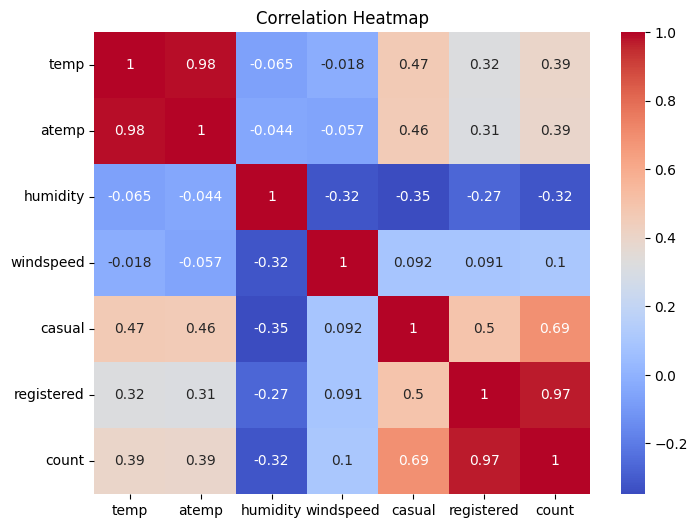

In [29]:
correlation = df[numerical].corr()
plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

The correlation analysis confirms that temp and atemp are highly correlated (0.98), indicating that they contain very similar information. Since this project focuses on building simple and interpretable models, both variables will be retained. The variables casual and registered show very strong correlations with the target variable because they directly contribute to the total bike rental count. However, they will be excluded before model training to prevent data leakage. Overall, temperature, season and weather appear to be the most informative predictors, while humidity shows a moderate negative relationship and wind speed exhibits only a weak linear association with bike demand.